In [1]:
from maze_nca.config import EnvConfig
from maze_nca.nca import NCAModel
from maze_nca.task_generation import generate_task, generate_batch
from maze_nca.utils import plot_channel, benchmark_reward
import tensorflow as tf

## Visualizing Task Channels

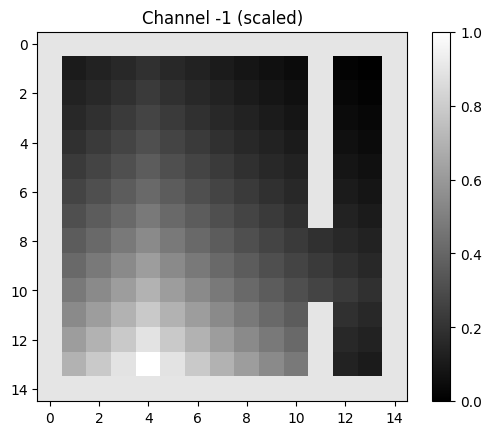

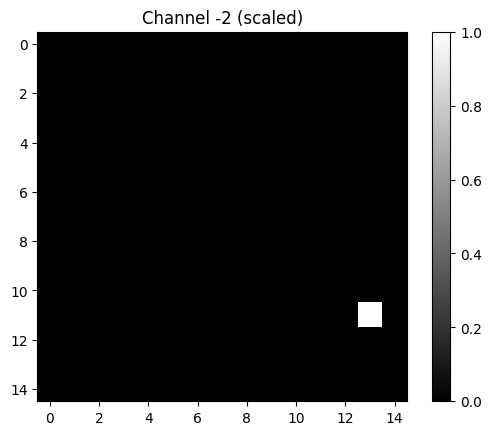

In [2]:
# Visualize Channels
sim_config = EnvConfig()
ca = NCAModel(
    config = sim_config.to_tf_nca_cfg()
)
env = generate_task(
    sim_config.to_tf_task_cfg(),
    seed=tf.constant([1, 1], tf.int32)
)
env = ca.egg(env)
plot_channel(env, -1)
plot_channel(env, -2)

## Benchmarking Reward Function

In [3]:
sim_config = EnvConfig(
    activity_cost=5,
    VI_goal_reward=0,
    VI_step_cost=1,
    reward_temperature=1e-1,
    alive_scaled=False,
    max_height=10,
    max_width=10,
)

ca = NCAModel(config = sim_config.to_tf_nca_cfg())

benchmark_reward(
    sim_config,
    ca,
    batch_size=10,
    base_seed=tf.constant([1, 1], tf.int32)
)


    Starting Reward: 4.604816862770424e-17
    Goal Reward: 0.39682406187057495
    Space-Filled Reward: 0.008044863119721413
    Half-Space-Filled Reward: 0.008044863119721413
    Self-Destruct Reward: 0.0
    


## Testing NCA Behavior

In [6]:
sim_config = EnvConfig(
    activity_cost=5,
    VI_goal_reward=0,
    VI_step_cost=1,
    reward_temperature=1e-1,
    alive_scaled=False,
    max_height=10,
    max_width=10,
    death_threshold=0.001,
    avg_signal_threshold=0.001,
    live_init=1.0
)
task_cfg = sim_config.to_tf_task_cfg()
nca_cfg = sim_config.to_tf_nca_cfg()

ca = NCAModel(config=nca_cfg)

tasks = generate_batch(
    tf_task_cfg = task_cfg,
    batch_size = 10,
    task_shape = sim_config.get_task_shape(),
    base_seed = tf.constant([1, 1], dtype=tf.int32)
)

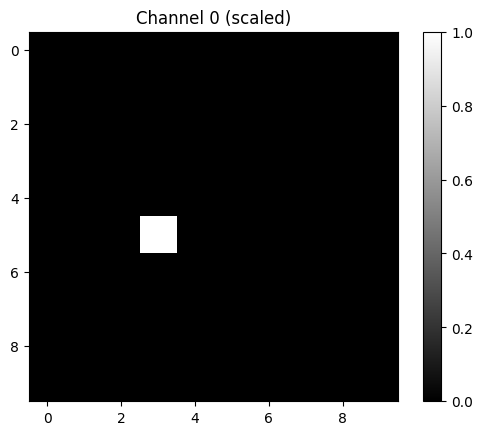

raw delta Tensor("strided_slice_8:0", shape=(10, 10), dtype=float32)
dampened delta Tensor("strided_slice_9:0", shape=(10, 10), dtype=float32)
new_state Tensor("strided_slice_10:0", shape=(10, 10), dtype=float32)
raw delta tf.Tensor(
[[-0.         -0.         -0.         -0.         -0.         -0.
  -0.         -0.         -0.         -0.        ]
 [-0.         -0.         -0.          0.          0.          0.
   0.          0.          0.         -0.        ]
 [-0.         -0.         -0.         -0.         -0.         -0.
   0.          0.          0.         -0.        ]
 [-0.         -0.         -0.         -0.         -0.          0.
   0.          0.          0.         -0.        ]
 [-0.         -0.         -1.3023866  -0.17583871  0.          0.
   0.          0.          0.         -0.        ]
 [-0.         -0.         -0.          3.2017272   0.8985599   0.
   0.          0.         -0.         -0.        ]
 [-0.         -0.         -0.         -0.81886494 -0.          0

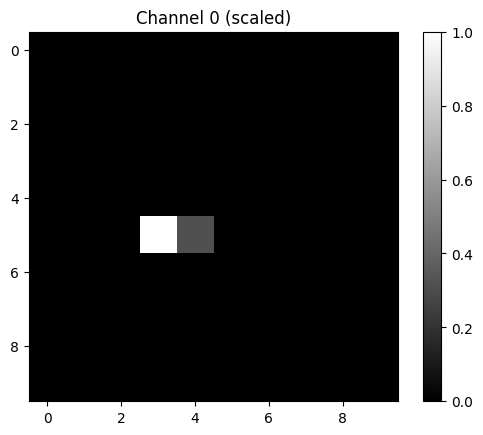

raw delta tf.Tensor(
[[-0.         -0.         -0.         -0.         -0.         -0.
  -0.         -0.         -0.         -0.        ]
 [-0.         -0.         -0.          0.          0.          0.
   0.          0.          0.         -0.        ]
 [-0.         -0.         -0.         -0.         -0.         -0.
   0.          0.          0.         -0.        ]
 [-0.         -0.         -0.         -0.         -0.          0.
   0.          0.          0.         -0.        ]
 [-0.         -0.         -1.9472635  -1.3950012  -0.          0.
   0.          0.          0.         -0.        ]
 [-0.         -0.         -0.          1.8224111   1.064583    0.
   0.          0.         -0.         -0.        ]
 [-0.         -0.         -0.         -0.39083087  0.          0.
  -0.         -0.         -0.         -0.        ]
 [-0.         -0.         -0.         -0.         -0.          0.
   0.          0.          0.         -0.        ]
 [-0.         -0.         -0.         -0.  

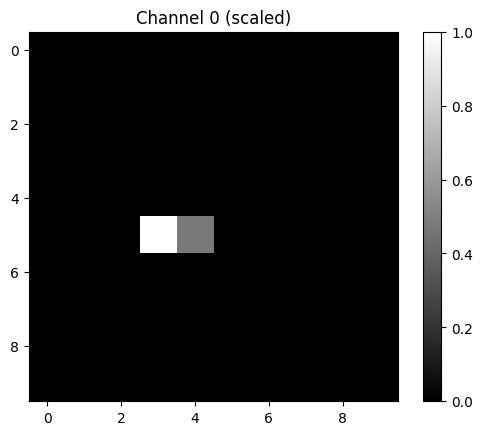

raw delta tf.Tensor(
[[-0.         -0.         -0.         -0.         -0.         -0.
  -0.         -0.         -0.         -0.        ]
 [-0.         -0.         -0.          0.          0.          0.
   0.          0.          0.         -0.        ]
 [-0.         -0.         -0.         -0.         -0.         -0.
   0.          0.          0.         -0.        ]
 [-0.         -0.         -0.         -0.         -0.          0.
   0.          0.          0.         -0.        ]
 [-0.         -0.         -2.6539168  -2.8739219  -0.          0.
   0.          0.          0.         -0.        ]
 [-0.         -0.         -0.          0.50960064  0.9731469   0.
   0.          0.         -0.         -0.        ]
 [-0.         -0.         -0.         -0.21013755  0.          0.
  -0.         -0.         -0.         -0.        ]
 [-0.         -0.         -0.         -0.         -0.          0.
   0.          0.          0.         -0.        ]
 [-0.         -0.         -0.         -0.  

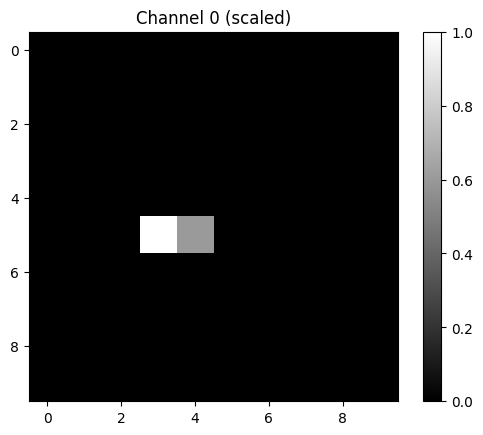

raw delta tf.Tensor(
[[-0.         -0.         -0.         -0.         -0.         -0.
  -0.         -0.         -0.         -0.        ]
 [-0.         -0.         -0.          0.          0.          0.
   0.          0.          0.         -0.        ]
 [-0.         -0.         -0.         -0.         -0.         -0.
   0.          0.          0.         -0.        ]
 [-0.         -0.         -0.         -0.         -0.          0.
   0.          0.          0.         -0.        ]
 [-0.         -0.         -3.102189   -4.056342   -0.          0.
   0.          0.          0.         -0.        ]
 [-0.         -0.         -0.          0.23350906  2.1392984   0.
   0.          0.         -0.         -0.        ]
 [-0.         -0.         -0.         -0.21222675  0.          0.
  -0.         -0.         -0.         -0.        ]
 [-0.         -0.         -0.         -0.         -0.          0.
   0.          0.          0.         -0.        ]
 [-0.         -0.         -0.         -0.  

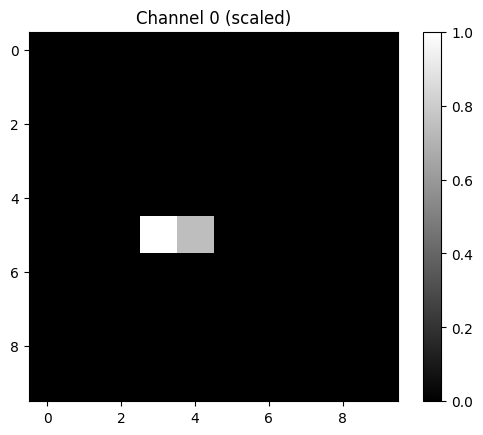

raw delta tf.Tensor(
[[-0.         -0.         -0.         -0.         -0.         -0.
  -0.         -0.         -0.         -0.        ]
 [-0.         -0.         -0.          0.          0.          0.
   0.          0.          0.         -0.        ]
 [-0.         -0.         -0.         -0.         -0.         -0.
   0.          0.          0.         -0.        ]
 [-0.         -0.         -0.         -0.         -0.          0.
   0.          0.          0.         -0.        ]
 [-0.         -0.         -3.4730515  -5.1126757  -0.         -0.
   0.          0.          0.         -0.        ]
 [-0.         -0.         -0.          0.20202065  2.847009    0.
   0.          0.         -0.         -0.        ]
 [-0.         -0.         -0.         -0.21366727  0.          0.
  -0.         -0.         -0.         -0.        ]
 [-0.         -0.         -0.         -0.         -0.          0.
   0.          0.          0.         -0.        ]
 [-0.         -0.         -0.         -0.  

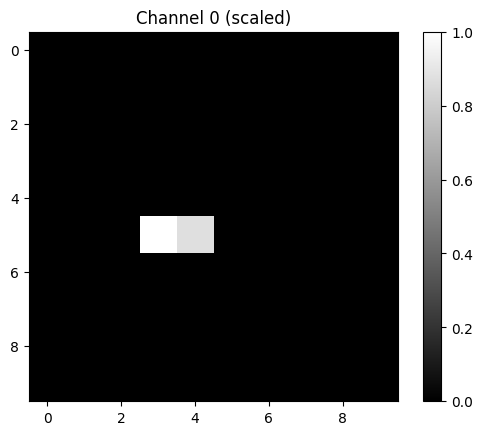

In [7]:
seed = tf.constant([1, 1], tf.int32)

world = ca.egg(tasks)
plot_channel(world[0, ...], 0)

for _ in range(5):
    world = ca(
        world=world,
        seed=seed
    )
    
    plot_channel(world[0, ...], 0)